<hr size=5 color='#002883'>

<p align="center"> <font size=7 color='#002883'> Geração do arquivo Track de ciclones e furacões para o processamento dos balanços de energia, vorticidade e massa com o software ATMOSBUD

<hr size=5 color='#002883'>

<p align="left"> <font size=5 color='#002883'> Professores:  

* Prof. Dr. Pedro Leite da Silva Dias
* Prof. Dr. Ricardo Hallak


<p align="left"> <font size=5 color='#002883'> Estudante:

* Ronald Guiuseppi Ramírez Nina [PhD. Candidate in Atmospheric Sciences]
* email: ronald.ramirez.nina@alumni.usp.br / ronald.ramirez.nina@usp.br

<hr size=5 color='#002883'>

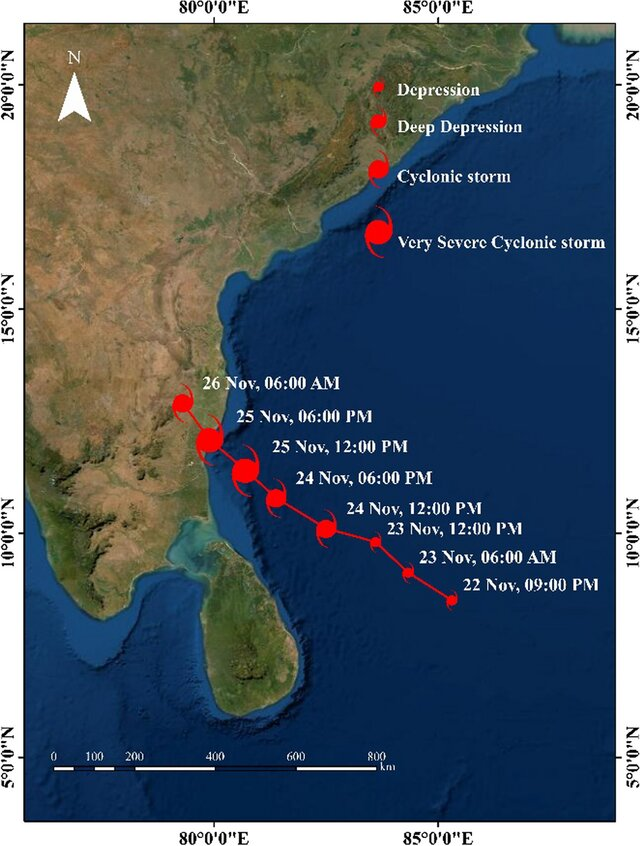

<hr size=5 color='#002883'>

# <font size=6 color='#002883'> **1. preparação do Colab** <font>

<font size=4 color='#002883'> Depois de instalar as livrarias é necessário **Reiniar** o ambiente de trabalho. Fazer clic em **Reiniciar sessão ou Restart session** no menú de Runtime ou Execução. Outra opção é executar a seguinte célula. O comando os.kill(os.getpid(), 9) reinicia a seção. Ignorar as mensagem que aparecem depois de executar essa célular.<font>

<font size=4 color='red'> Outra opção é executar a célula de ponto **1.1. "Reiniciar sessão"**. O comando os.kill(os.getpid(), 9) reinicia a seção. Ignorar as mensagem que aparecem depois de executar essa célular.<font>

In [1]:
# @title #### <font color='#002883'> Instalar livrarias <font>
%%capture
!pip install xarray netCDF4 scipy scikit-learn dask pydap bottleneck h5netcdf
!pip install store zarr
!pip install uv
!pip install cartopy
!pip install cmocean
!pip -q install ipympl

<font size=4 color='#002883'> **1.1. Reiniciar sessão.**<font>

In [ ]:
# @title #### <font color='#002883'> Reiniciar sessão executando a célula <font>
%%capture

import os
os.kill(os.getpid(), 9)

<font size=4 color='#002883'> **2. Importar livrarias e montar o drive** <font>

In [1]:
# @title #### <font color='#002883'> Importar livrarias <font>
#%%capture
from google.colab import output
output.enable_custom_widget_manager()

<font size=4 color='#002883'> **3. Instalar o widget para visualização na hora de escolher a área do ciclone ou furacão** <font>

In [2]:
# @title #### <font color='#002883'> Instalar o widget <font>
#%%capture
%matplotlib widget

<font size=4 color='#002883'> **4. Importar livrarias e montar o drive** <font>

In [3]:
# @title #### <font color='#002883'> Importar livrarias e montar o drive <font>
#%%capture
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from matplotlib.widgets import RectangleSelector
import ipywidgets as widgets
from IPython.display import display

import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Importar o drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<hr size=5 color='#002883'>

# <font size=6 color='#002883'> **4. Acessar aos dados do [Earth Data catalogue](https://earthdatahub.destine.eu/catalogue)** <font>

- <font size=4 color='#002883'>Earth Data catalogue link: [Earth Data catalogue](https://earthdatahub.destine.eu/catalogue) <font>

<font size=4 color= '#002883'>**Acessar ao Site e criar uma conta, no qual vocês poderão criar seus própios tokens, necessários para fazer usso dos diferentes conjuntos de dados disponíveis <font>**.

<font size=4 color= 'red'>**Observação: O token do exemplo é temporário, por tal motivo é possível que se você não mudar com seu próprio token a seguinte célula não consiga ser executada. <font>**.

In [4]:
# @title #### <font color='#002883'> Acessar através do access token <font>
%%capture
token = "edh_pat_d2c59b08304ab1489023f5c02db65f5bf6fc852132871ec4f00bd467d161b66655d85b2a7415725b7c2b6ca8bfed27c0"
edh_pat = os.getenv("EDH_PAT", token)

assert edh_pat.startswith("edh_pat_"), (
    f"Your personal access token is a long string starting with 'edh_pat_', not {edh_pat!r}"
)

<font size=4 color='#002883'> **5. Ler o dataset horário do ERA5
utilizando o token** <font>

<font size=4 color='#002883'> **Se acessa ao conjunto de dados do ERA5 Single Levels, devido a que a variável de interesse para o track do ciclone/furacão é a pressão reduzida ao nível medio do mar.** <font>

In [5]:
# @title #### <font color='#002883'> Ler dataset utiizando o token  <font>
#%%capture

# Link de acesso aos dados horários por níveis de pressão de todo o histórico do ERA5
link_era5_single_levels = "data.earthdatahub.destine.eu/era5/reanalysis-era5-single-levels-v0.zarr"
# Ler dataset
era5_single_levels_hourly = xr.open_dataset(
    f"https://edh:{edh_pat}@{link_era5_single_levels}",
    chunks={},
    engine="zarr",
)

# Display dos dados
era5_single_levels_hourly

<xarray.Dataset> Size: 406TB
Dimensions:     (valid_time: 757512, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2026-05-31T23:...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    surface     float64 8B ...
Data variables: (12/129)
    alnid       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    alnip       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    aluvd       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    aluvp       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    anor        (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    asn         (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    ...          ...
    viiwn       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    vilwd       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    vilwe       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    vilwn       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    z           (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    zust        (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-12-04T16:25 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

<font size=4 color='#002883'> **6. Selecionar a área de estudo, em função do ciclone/furacão de interesse. Neste caso, como exemplo foi eleito o furacão Catarina. Converter as longitudes do formato de 0° a 360° para o formato de -180° a +180° (Porém, se for necessário pode manter o formato de 0° - 360°). Selecionar o período de estudo (e.g., O furacão Catarina aconteceu entre 20 de março de 2004 até o dia 28 de março de 2004).** <font>

In [6]:
# @title #### <font color='#002883'> Selecionar a área, tranfomar o formato das longitudes e escolher o período  <font>
#%%capture

# Selecionar área e período
# Data inicial
start_time = '2004-03-20'
# Data final
end_time = '2004-03-28'

# Selecionar as latitudes e longitudes minima e máximo
lon_min = -70
lon_max = -20
lat_min = -50
lat_max = -15

# Selecionar período
ds = era5_single_levels_hourly.sel(
    latitude=slice(lat_max, lat_min),
    valid_time=slice(start_time,end_time)
)

# Dar atributos à coordenada de tempo
ds["valid_time"].attrs.update({
    "long_name": "time",
    "standard_name": "time",
})

# Variáveis selecionadas para o ATMOSBUD
vars_keep = ["msl"]
ds = ds[vars_keep]

# Transformar o formato das longitudes
ds['longitude'] = (ds.coords['longitude'] + 180) % 360 - 180
ds = ds.sortby(ds.longitude)
# Selecionar área e período
ds = ds.sel(
    longitude=slice(lon_min, lon_max)
)

# Selecionar os pasos de tempo, e.g., time_step = 3 horas ou 6 horas
time_step = 6 # horas: Pode trocar para 3
hours_keep = list(range(0,24,time_step))
ds = ds.sel(
    valid_time = ds.valid_time.dt.hour.isin(hours_keep)
)

# Visualizar o dataset
ds

<xarray.Dataset> Size: 19MB
Dimensions:     (valid_time: 36, latitude: 337, longitude: 401)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 288B 2004-03-20 ... 2004-03-28T18...
  * latitude    (latitude) float64 3kB 12.0 11.75 11.5 ... -71.5 -71.75 -72.0
  * longitude   (longitude) float64 3kB -120.0 -119.8 -119.5 ... -20.25 -20.0
    number      int64 8B ...
    surface     float64 8B ...
Data variables:
    msl         (valid_time, latitude, longitude) float32 19MB dask.array<chunksize=(36, 8, 8), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-12-04T16:25 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

<font size=4 color='#002883'> **7. Salvar o dataset do ERA5 como um NetCDF file. É necessário escrever o path (caminho) do espaço em nosso drive onde ele será direcionado com o objetivo de ser utilizado para outros processos (e.g., como input do ATMOSBUD). Salvar o NetCDF precisa de um tempo de vários minutos em função do período escolhido, os passos de tempo (a cada 3, 6 ou 12 horas) e o tamanho da área selecionada. No possível fazer isso com anticipação.** <font>

In [7]:
# @title #### <font color='#002883'> Salvar NetCDF file no meu drive  <font>
#%%capture

# Editar o path do seu respectivo espaço de trabalho do seu drive
path_out = "/content/drive/MyDrive/equipe4_catarina_msl.nc"

# Procedimento para obter um file NetCDF de menor tamanho
comp = dict(zlib=True, complevel=5)
encoding = {var: comp for var in ds.data_vars}

# Salvar NetCDF file
ds.to_netcdf(path_out, encoding=encoding, compute=True)

<font size=4 color='#002883'> **8. Estabelcer configurações antes de executar as funções que permitem criar o arquivo do track do ciclone** <font>

In [8]:
# @title #### <font color='#002883'> Configurações antes de gerar o arquivo do track <font>
#%%capture

# ==========================================================
# CONFIGURAÇÃO
# ==========================================================
# Caminho do arquivo de pressão reduzida ao nível do mar
file_nc = "/content/drive/MyDrive/equipe4_catarina_msl.nc"

# Para pressão ao nível médio do mar, normalmente:
varname = "msl"
level_value = None

# Se você quiser usar altura geopotencial em 850 hPa, use:
# varname = "z"
# level_value = 850

# Caminho do arquivo track que será criado
outfile = "/content/track_cyclone_catarina.txt"

# Para fazer um loop para cada passo de tempo
time_step = 1


<font size=4 color='#002883'> **9. Rodar a celda e escolher a área do cilone. Uma vez estabelecida a caixa, dar click na opção "Salvar caixa"** <font>

Arquivo aberto com sucesso.
Variável: msl
Tempo: valid_time, total de passos: 36
Latitude: -72.00 a 12.00
Longitude: -120.00 a -20.00
Arquivo de saída criado: /content/track_cyclone_catarina.txt


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


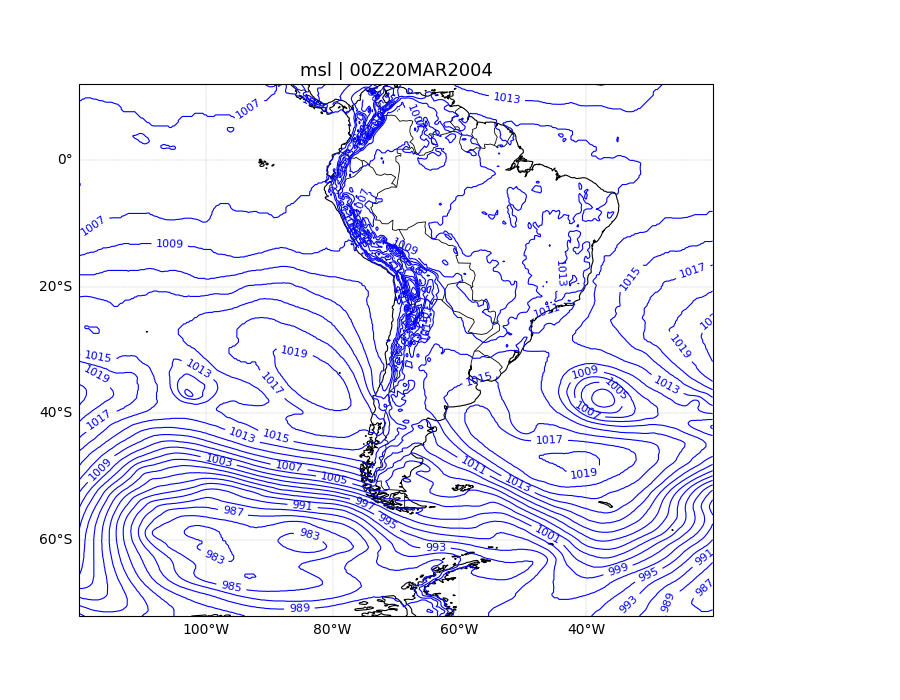

In [9]:
# @title #### <font color='#002883'> Selecionar área do ciclone ou furacão e salvar a caixa <font>
#%%capture

# ==========================================================
# FUNÇÕES AUXILIARES
# ==========================================================

def find_coord_name(ds, candidates):
    """
    Detecta automaticamente o nome de uma coordenada.
    """
    for name in ds.coords:
        if name.lower() in candidates:
            return name

    for name in ds.dims:
        if name.lower() in candidates:
            return name

    return None


def convert_field_for_plot(da):
    """
    Converte a variável para uma unidade mais adequada para plot.

    - msl em Pa -> hPa
    - z em m² s⁻² -> m
    """
    name = str(da.name).lower()
    units = str(da.attrs.get("units", "")).lower()
    long_name = str(da.attrs.get("long_name", "")).lower()

    if name == "z" or "geopotential" in long_name:
        da_plot = da / 9.80665
        label = "Geopotential height [m]"

    elif units in ["pa", "pascal", "pascals"] or float(da.mean()) > 2000:
        da_plot = da / 100.0
        label = "Pressure [hPa]"

    else:
        da_plot = da
        label = f"{da.name}"

        if units:
            label += f" [{units}]"

    return da_plot, label


def make_levels(da_plot):
    """
    Cria níveis automáticos para contour.
    Para pressão em hPa, usa intervalo de 2 hPa.
    Para outras variáveis, usa 20 níveis.
    """
    values = da_plot.values
    vmin = np.nanmin(values)
    vmax = np.nanmax(values)

    if vmin > 800 and vmax < 1100:
        return np.arange(np.floor(vmin), np.ceil(vmax) + 2, 2)
    else:
        return np.linspace(vmin, vmax, 20)


# ==========================================================
# ABRIR DATASET
# ==========================================================

ds = xr.open_dataset(file_nc)

# Selecionar nível de pressão, se solicitado
if level_value is not None:
    possible_level_names = ["level", "pressure_level", "isobaricInhPa", "plev", "lev"]

    level_name = None
    for name in possible_level_names:
        if name in ds.coords or name in ds.dims:
            level_name = name
            break

    if level_name is None:
        raise ValueError("Não encontrei coordenada de nível de pressão no arquivo.")

    ds = ds.sel({level_name: level_value}, method="nearest")
    print(f"Nível selecionado: {level_name} = {float(ds[level_name].values)}")


# Detectar nomes das coordenadas
lat_name = find_coord_name(ds, ["lat", "latitude"])
lon_name = find_coord_name(ds, ["lon", "longitude"])
time_name = find_coord_name(ds, ["time", "valid_time", "date"])

if lat_name is None or lon_name is None or time_name is None:
    raise ValueError("Não consegui detectar latitude, longitude ou tempo automaticamente.")

if varname not in ds:
    raise ValueError(f"A variável '{varname}' não existe no arquivo. Variáveis disponíveis: {list(ds.data_vars)}")

da_all = ds[varname].squeeze(drop=True)

# Subamostrar no tempo, se quiser
da_all = da_all.isel({time_name: slice(None, None, time_step)})

lat = ds[lat_name]
lon = ds[lon_name]

lat_min = float(lat.min())
lat_max = float(lat.max())
lon_min = float(lon.min())
lon_max = float(lon.max())

nt = len(da_all[time_name])

print("Arquivo aberto com sucesso.")
print(f"Variável: {varname}")
print(f"Tempo: {time_name}, total de passos: {nt}")
print(f"Latitude: {lat_min:.2f} a {lat_max:.2f}")
print(f"Longitude: {lon_min:.2f} a {lon_max:.2f}")


# ==========================================================
# CRIAR ARQUIVO DE SAÍDA
# ==========================================================

with open(outfile, "w") as f:
    f.write("time;Lat;Lon;length;width\n")

print(f"Arquivo de saída criado: {outfile}")


# ==========================================================
# FIGURA INTERATIVA
# ==========================================================

fig = plt.figure(figsize=(9, 7))

ax = fig.add_axes([0.08, 0.12, 0.72, 0.76], projection=ccrs.PlateCarree())

selection = {}
current = {"i": 0}
selector_holder = {"selector": None}

status = widgets.HTML(value="<b>Status:</b> selecione uma caixa no mapa.")

time_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=nt - 1,
    step=1,
    description="Time:",
    continuous_update=False,
    layout=widgets.Layout(width="70%")
)

save_button = widgets.Button(
    description="Salvar caixa",
    button_style="success"
)

skip_button = widgets.Button(
    description="Pular tempo",
    button_style="warning"
)


def draw_time(i):
    """
    Desenha o campo meteorológico no tempo selecionado.
    """
    ax.clear()
    selection.clear()
    current["i"] = int(i)

    da = da_all.isel({time_name: int(i)})
    da_plot, cbar_label = convert_field_for_plot(da)
    levels = make_levels(da_plot)

    time_value = pd.to_datetime(da_all[time_name].isel({time_name: int(i)}).values)
    time_title = time_value.strftime("%HZ%d%b%Y").upper()

    # Contornos
    cs = ax.contour(
        lon,
        lat,
        da_plot,
        levels=levels,
        colors="blue",
        linewidths=0.8,
        transform=ccrs.PlateCarree()
    )

    ax.clabel(cs, inline=True, fontsize=8, fmt="%.0f")

    ax.coastlines(resolution="50m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6)
    ax.add_feature(cfeature.STATES, linewidth=0.4)

    ax.set_extent(
        [lon_min, lon_max, lat_min, lat_max],
        crs=ccrs.PlateCarree()
    )

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.6, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(f"{varname} | {time_title}", fontsize=13)

    def onselect(eclick, erelease):
        lon_a, lat_a = eclick.xdata, eclick.ydata
        lon_b, lat_b = erelease.xdata, erelease.ydata

        if lon_a is None or lon_b is None or lat_a is None or lat_b is None:
            status.value = "<b>Status:</b> seleção fora do mapa. Tente novamente."
            return

        lon_left = min(lon_a, lon_b)
        lon_right = max(lon_a, lon_b)
        lat_bottom = min(lat_a, lat_b)
        lat_top = max(lat_a, lat_b)

        selection["lon_left"] = lon_left
        selection["lon_right"] = lon_right
        selection["lat_bottom"] = lat_bottom
        selection["lat_top"] = lat_top

        lon_center = (lon_left + lon_right) / 2.0
        lat_center = (lat_bottom + lat_top) / 2.0
        length = lon_right - lon_left
        width = lat_top - lat_bottom

        status.value = (
            "<b>Status:</b> caixa selecionada: "
            f"Lat={lat_center:.2f}, Lon={lon_center:.2f}, "
            f"length={length:.2f}, width={width:.2f}"
        )

    selector = RectangleSelector(
        ax,
        onselect,
        useblit=False,
        button=[1],
        minspanx=0.1,
        minspany=0.1,
        spancoords="data",
        interactive=True
    )

    selector_holder["selector"] = selector

    status.value = (
        f"<b>Status:</b> tempo {int(i)+1}/{nt}. "
        "Clique, arraste e solte para selecionar a área do ciclone."
    )

    fig.canvas.draw_idle()


def save_selection(_):
    """
    Salva a caixa selecionada no formato do ATMOS-BUD:
    time;Lat;Lon;length;width
    """
    if not selection:
        status.value = "<b>Status:</b> nenhuma caixa selecionada. Desenhe uma caixa antes de salvar."
        return

    i = current["i"]

    time_value = pd.to_datetime(da_all[time_name].isel({time_name: i}).values)
    time_txt = time_value.strftime("%Y-%m-%d-%H%M")

    lon_left = selection["lon_left"]
    lon_right = selection["lon_right"]
    lat_bottom = selection["lat_bottom"]
    lat_top = selection["lat_top"]

    lon_center = (lon_left + lon_right) / 2.0
    lat_center = (lat_bottom + lat_top) / 2.0
    length = lon_right - lon_left
    width = lat_top - lat_bottom

    with open(outfile, "a") as f:
        f.write(
            f"{time_txt};"
            f"{lat_center:.4f};"
            f"{lon_center:.4f};"
            f"{length:.4f};"
            f"{width:.4f}\n"
        )

    status.value = (
        "<b>Status:</b> salvo: "
        f"{time_txt};{lat_center:.4f};{lon_center:.4f};{length:.4f};{width:.4f}"
    )

    # Avançar automaticamente para o próximo tempo
    if i < nt - 1:
        time_slider.value = i + 1


def skip_time(_):
    """
    Pula o tempo atual sem salvar caixa.
    """
    i = current["i"]

    if i < nt - 1:
        time_slider.value = i + 1
    else:
        status.value = "<b>Status:</b> último tempo alcançado."


def on_slider_change(change):
    """
    Atualiza a figura quando o usuário muda o tempo.
    """
    if change["name"] == "value":
        draw_time(change["new"])


time_slider.observe(on_slider_change, names="value")
save_button.on_click(save_selection)
skip_button.on_click(skip_time)

controls = widgets.VBox([
    time_slider,
    widgets.HBox([save_button, skip_button]),
    status
])

display(controls)

draw_time(0)

<font size=4 color='#002883'> **10. Copiar o conteúdo do file do track do ciclone em uma pasta do nosso drive** <font>

In [10]:
# @title #### <font color='#002883'> Copiar o arquivo track em nosso drive <font>
#%%capture
!cp /content/track_cyclone_catarina.txt /content/drive/MyDrive/track_cyclone_catarina.txt